In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, LinearAlgebra, StatsBase;

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [3]:
lattice_vectors = loadlattice("wannier.out")

3-element Vector{Vector{Float64}}:
 [-6.2541842099, 2.1665141392400002, 0.0]
 [1.25083684198, -6.499563584800001, 0.0]
 [0.0, 0.0, 21.16708]

In [77]:
A = unit_cell_area(lattice_vectors)

37.93951223926523

In [14]:
Hwannierup, cellmapup = hwannier("wannierUp.txt", "wannierUp.map.txt"), np.loadtxt("wannierUp.map.txt");
Hwannierdn, cellmapdn = hwannier("wannierDn.txt", "wannierDn.map.txt"), np.loadtxt("wannierDn.map.txt");
force_matrix, phonon_cell_map = phonon_force_matrix("totalE");
HePhWannier, cellMapEph = write_eph_matrix_elements("wannier", 29*3, [1, 1, 1], Val('u'));


Number of phonon modes is: 87
If this is incorrect, something went wrong somewhere at some point.


In [221]:
function self_energy(HWannier::Array{Float64, 3}, cell_map::Array{Float64, 2}, HePhWannier::Array{<:Real, 5},
    cellMapEph::Array{<:Real, 2}, force_matrix::Array{<:Real, 3}, phonon_cell_map::Array{<:Real, 2}, qnormalized::Vector{<:Real}, μ::Real; histogram_width::Real=100, offset::Real = 5, mesh::Integer=30) 

    self_energies = zeros(histogram_width*20)

    for (xmesh, ymesh) in Tuple.(CartesianIndices(rand(mesh, mesh)))
        phonon_energies = phonon_dispersion(force_matrix, phonon_cell_map, [xmesh/mesh, ymesh/mesh, 0])
        phonon_mat_elements= eph_matrix_elements(HePhWannier, cellMapEph, force_matrix, phonon_cell_map, qnormalized, [xmesh/mesh, ymesh/mesh, 0]+qnormalized)
        ϵf = wannier_bands(HWannier, cell_map, [xmesh/mesh, ymesh/mesh, 0]+qnormalized)
        fermi = ϵf<μ ? 1 : 0
        for (idx, ωph) in enumerate(phonon_energies)
            self_energies[round(Int, (ϵf-μ+ωph+offset)*histogram_width)] += -π*abs(phonon_mat_elements[idx])^2*(1-fermi)*histogram_width/mesh^2
            self_energies[round(Int, (ϵf-μ-ωph+offset)*histogram_width)] += -π*abs(phonon_mat_elements[idx])^2*(fermi)*histogram_width/mesh^2
        end
    end
    return self_energies
end


self_energy (generic function with 2 methods)

In [287]:
function spectral(ϵ_, ϵ, im_e; histogram_width::Real = 100, δ::Real=0)
    imag_part = try 
        im_e[round(Int,(ϵ_ -μ+10)*histogram_width)]
    catch
        0
    end
    spectral = try 
    -2*imag(1/(ϵ_ -ϵ + μ +1im*δ-1im*imag_part))
    catch 
        0
    end
    return spectral
end

spectral (generic function with 6 methods)

In [273]:
q=[0.01, 0, 0]
μ = -2.6

spectral_sum = 0 
N=3
ω = 0.3
for i in 1:N
    println(i)
    flush(stdout)
    for j in 1:N
        k = [i/N, j/N, 0]
        im_ek = self_energy(Hwannierup, cellmapup, HePhWannier, cellMapEph, force_matrix, phonon_cell_map, k, -2.6, offset = 10, histogram_width=100, mesh=5)
        ϵk = wannier_bands(Hwannierup, cellmapup, k)
        im_ekq = self_energy(Hwannierup, cellmapup, HePhWannier, cellMapEph, force_matrix, phonon_cell_map, k+q, -2.6, offset = 10, histogram_width=100, mesh=5)
        ϵkq = wannier_bands(Hwannierup, cellmapup, k+q)
        
        Ak = spectral.(e_range, ϵk, Ref(im_ek))
        Akq = spectral.(e_range .+ ω, ϵkq, Ref(im_ekq))
        spectral_sum += sum(Ak.*Akq)/N^2

        #spectral_sum += sum(Ak.*Akq.*(JJDFTX.heaviside.(μ .- e_range) .- JJDFTX.heaviside.(μ .- e_range .- ω)))/N^2
    end
end



1
2
3


In [274]:
e²ϵ/4*20/100*1/4*1/π*1/A*spectral_sum/ħ

3.744535508845679e10

In [211]:
e_range

100-element Vector{Float64}:
 -10.0
  -9.797979797979798
  -9.595959595959595
  -9.393939393939394
  -9.191919191919192
  -8.98989898989899
  -8.787878787878787
  -8.585858585858587
  -8.383838383838384
  -8.181818181818182
  -7.97979797979798
  -7.777777777777778
  -7.575757575757576
   ⋮
   7.777777777777778
   7.97979797979798
   8.181818181818182
   8.383838383838384
   8.585858585858587
   8.787878787878787
   8.98989898989899
   9.191919191919192
   9.393939393939394
   9.595959595959595
   9.797979797979798
  10.0

In [275]:
k = [-0.2, 0.3, 0]
q = [0.5, 0, 0]
im_ek = self_energy(Hwannierup, cellmapup, HePhWannier, cellMapEph, force_matrix, phonon_cell_map, k, -2.6, offset = 10, histogram_width=100, mesh=10)
ϵk = wannier_bands(Hwannierup, cellmapup, k)
im_ekq = self_energy(Hwannierup, cellmapup, HePhWannier, cellMapEph, force_matrix, phonon_cell_map, k+q, -2.6, offset = 10, histogram_width=100, mesh=10)
ϵkq = wannier_bands(Hwannierup, cellmapup, k+q)

;

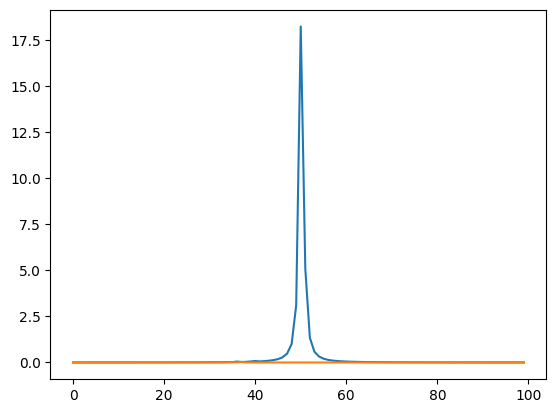

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7fec4a014670>

In [288]:
Ak = spectral.(e_range, ϵk, Ref(im_ek),δ= 0.1)        
#Akq = spectral.(e_range .+ 0.5, ϵkq, Ref(im_ekq))

plot(Ak)
plot(Akq)

In [291]:
sum(Ak)*20/100

6.503002406286123

In [283]:
sum(Ak)

0.0

In [140]:
e²ϵ/4*20/100*1/4*1/π*1/ħ*1/A*spectral_sum

0.0

In [121]:
e²ϵ/4*20/100*1/4*1/pi*1/A*spectral_sum

1.852004247774555

In [104]:
e_range = collect(range(-10, 10, length = 100))
x = spectral.(e_range)
y = spectral.(e_range .+ 0.5)
e²ϵ/4*sum(x .* y)*20/100*1/4*1/π*1/ħ*1/A

6.09449308542531e14

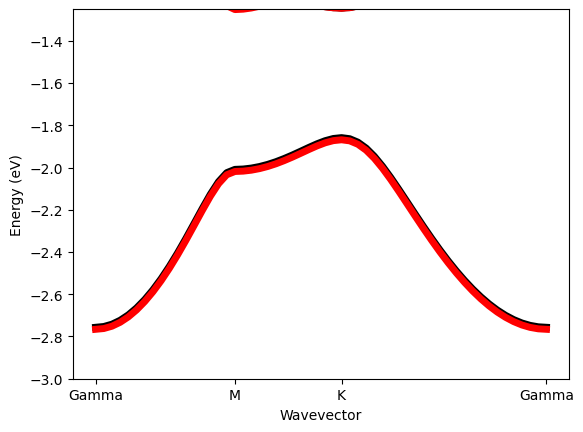

(-3.0, -1.25)

In [13]:
plotwannierbands(Hwannierup, cellmapup, 1, linewidth=3, color="red")
plotwannierbands(Hwannierdn, cellmapdn, 1, linewidth=3, color="black")
plot_bands("../Na-bands.eigenvals", spin=2)
ylim(-3, -1.25)